In [9]:
# ============================================================
# FULL YOLOv8 TRAINING CODE FOR IDA SRI LANKAN DATASET
# Classes:
# 0 - Pencil
# 1 - Microcytosis
# 2 - Hypochromia
# 3 - Anisocytosis
# ============================================================

# Install Ultralytics
!pip install ultralytics -q

# Imports
import os
import glob
import yaml
import zipfile
import torch
from ultralytics import YOLO
from IPython.display import Image, display

# Mount Google Drive if running on Colab/remote GPU kernel
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("Google Drive mounted.")
except ImportError:
    print("Not running on Colab — skipping drive mount.")

Not running on Colab — skipping drive mount.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# 2. Set dataset paths (auto-detect environment)
# ============================================================
CANDIDATE_ROOTS = [
    "/content/drive/MyDrive/IDASrilankanDataset",                # Google Colab
    "/mnt/c/Users/ASUS/Desktop/Research/PP2/Dataset",            # WSL
    r"C:\Users\ASUS\Desktop\Research\PP2\Dataset",               # Local Windows
    os.path.join(os.getcwd(), "Dataset"),                        # Relative to notebook
]

ROOT = None
for path in CANDIDATE_ROOTS:
    if os.path.exists(os.path.join(path, "data.yaml")):
        ROOT = path
        break

if ROOT is None:
    raise FileNotFoundError(
        "Dataset not found in any known location. Searched:\n"
        + "\n".join(f"  - {p}" for p in CANDIDATE_ROOTS)
        + "\nPlease set ROOT manually to your dataset folder."
    )

DATA_YAML = os.path.join(ROOT, "data.yaml")

EPOCHS = 100
IMGSZ = 640
BATCH = 16 if torch.cuda.is_available() else 8
PATIENCE = 15
PROJECT = os.path.join(os.path.dirname(ROOT), "IDA_YOLOv8_runs")
RUN_NAME = "yolov8s_IDA_detection"
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)
print("Dataset root:", ROOT)
print("data.yaml exists:", os.path.exists(DATA_YAML))

Using device: cpu
Dataset root: C:\Users\ASUS\Desktop\Research\PP2\Dataset
data.yaml exists: True


In [3]:
# ============================================================
# 3. Read and fix YAML file paths
# ============================================================
with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["train"] = os.path.join(ROOT, "train", "images")
data_cfg["val"] = os.path.join(ROOT, "valid", "images")
data_cfg["test"] = os.path.join(ROOT, "test", "images")

fixed_yaml = os.path.join(ROOT, "data_fixed.yaml")
with open(fixed_yaml, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print("\nFixed data.yaml:")
print(data_cfg)



Fixed data.yaml:
{'train': 'C:\\Users\\ASUS\\Desktop\\Research\\PP2\\Dataset\\train\\images', 'val': 'C:\\Users\\ASUS\\Desktop\\Research\\PP2\\Dataset\\valid\\images', 'test': 'C:\\Users\\ASUS\\Desktop\\Research\\PP2\\Dataset\\test\\images', 'nc': 4, 'names': ['Anisocytosis', 'Hypochromia', 'Microcytosis', 'Pencil cells'], 'roboflow': {'workspace': 'sayuris-workspace', 'project': 'ida-hemora-sayuri-1111', 'version': 6, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/sayuris-workspace/ida-hemora-sayuri-1111/dataset/6'}}


In [4]:
# ============================================================
# 4. Detect whether labels are detection or segmentation
#    Detection label line: class x_center y_center width height
#    Segmentation label line: class x1 y1 x2 y2 x3 y3 ...
# ============================================================
def detect_task(label_dir):
    label_files = glob.glob(os.path.join(label_dir, "*.txt"))
    has_det = False
    has_seg = False
    for lf in label_files:
        with open(lf, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    has_det = True
                elif len(parts) > 5:
                    has_seg = True
    # If mixed labels exist, fall back to detection to avoid augmentation errors
    if has_det and has_seg:
        print("WARNING: Mixed detection and segmentation labels found — using detection mode.")
        return "detect"
    return "segment" if has_seg else "detect"

TASK = detect_task(os.path.join(ROOT, "train", "labels"))
MODEL_NAME = "yolov8s-seg.pt" if TASK == "segment" else "yolov8s.pt"

print("\nDetected task:", TASK)
print("Using model:", MODEL_NAME)


Detected task: detect
Using model: yolov8s.pt


In [5]:
# ============================================================
# 5. Count images and labels
# ============================================================
img_exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]

def count_images(folder):
    total = 0
    for ext in img_exts:
        total += len(glob.glob(os.path.join(folder, ext)))
    return total

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(ROOT, split, "images")
    lbl_dir = os.path.join(ROOT, split, "labels")
    n_img = count_images(img_dir) if os.path.exists(img_dir) else 0
    n_lbl = len(glob.glob(os.path.join(lbl_dir, "*.txt"))) if os.path.exists(lbl_dir) else 0
    print(f"{split}: images={n_img}, labels={n_lbl}")

train: images=114, labels=114
valid: images=15, labels=15
test: images=11, labels=11


In [6]:
# ============================================================
# 6. Load YOLOv8 model
# ============================================================
model = YOLO(MODEL_NAME)

In [7]:
# ============================================================
# 7. Train model
# ============================================================
results = model.train(
    data=fixed_yaml,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    patience=PATIENCE,
    project=PROJECT,
    name=RUN_NAME,
    pretrained=True,
    plots=True
)

Ultralytics 8.4.21  Python-3.13.7 torch-2.10.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ASUS\Desktop\Research\PP2\Dataset\data_fixed.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_IDA_detection, nbs=64, nms=False, opset=None, optimize=False, op

KeyboardInterrupt: 

In [ ]:
# ============================================================
# 8. Validate model
# ============================================================
print("\nRunning validation...")
val_metrics = model.val(
    data=fixed_yaml,
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE
)
print("Validation complete.")
print(val_metrics)



Running validation...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 19.7±4.0 MB/s, size: 23.5 KB)
val: Scanning /content/drive/MyDrive/IDASrilankanDataset/valid/labels.cache... 15 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 6.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 71, len(boxes) = 83. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all         15         83      0.349      0.127     0.0889     0.0779
          Anisocytosis          4          4          1          0    0.00254    0.00203
     

In [ ]:
# ============================================================
# 9. Predict on test images
# ============================================================
test_source = os.path.join(ROOT, "test", "images")
print("\nRunning predictions on test images...")

model.predict(
    source=test_source,
    imgsz=IMGSZ,
    conf=0.10,
    save=True,
    save_txt=True,
    save_conf=True,
    device=DEVICE,
    project=PROJECT,
    name=f"{RUN_NAME}_predictions",
    exist_ok=True
)


Running predictions on test images...

image 1/11 /content/drive/MyDrive/IDASrilankanDataset/test/images/02-25f11-hypochromia_jpg.rf.9b49cca8c3b88cef54885fa92b6ce824.jpg: 640x640 24 Hypochromias, 35 Microcytosiss, 16.2ms
image 2/11 /content/drive/MyDrive/IDASrilankanDataset/test/images/02-25f22-anisocytosis_jpg.rf.193ee866d0055635ee6cab3bedaec288.jpg: 640x640 3 Hypochromias, 23 Microcytosiss, 16.2ms
image 3/11 /content/drive/MyDrive/IDASrilankanDataset/test/images/02-25f25-microcytosis_jpg.rf.54be1e1cbbe9b47fbf1567edc6a77f6c.jpg: 640x640 2 Anisocytosiss, 20 Microcytosiss, 4 Pencil cellss, 16.2ms
image 4/11 /content/drive/MyDrive/IDASrilankanDataset/test/images/02-25f28-poikilocytosis_jpg.rf.38f14e4f464d0ce2c3a303c896f11e15.jpg: 640x640 2 Anisocytosiss, 32 Microcytosiss, 16.2ms
image 5/11 /content/drive/MyDrive/IDASrilankanDataset/test/images/02-25f29-poikilocytosis_jpg.rf.15809456c38fa23d0632319f843cd5e0.jpg: 640x640 51 Microcytosiss, 3 Pencil cellss, 16.1ms
image 6/11 /content/drive/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Anisocytosis', 1: 'Hypochromia', 2: 'Microcytosis', 3: 'Pencil cells'}
 obb: None
 orig_img: array([[[202, 194, 201],
         [202, 194, 201],
         [202, 194, 201],
         ...,
         [194, 187, 214],
         [193, 193, 211],
         [183, 189, 202]],
 
        [[202, 194, 201],
         [202, 194, 201],
         [202, 194, 201],
         ...,
         [194, 187, 214],
         [194, 194, 212],
         [185, 191, 204]],
 
        [[202, 194, 201],
         [202, 194, 201],
         [203, 195, 202],
         ...,
         [193, 186, 213],
         [194, 194, 212],
         [186, 192, 205]],
 
        ...,
 
        [[206, 190, 207],
         [206, 190, 207],
         [205, 189, 206],
         ...,
         [202, 189, 205],
         [202, 189, 205],
         [202, 189, 205]],
 
        [[207, 191, 208],
         [206, 190, 20

In [ ]:
# ============================================================
# 10. Save important output paths
# ============================================================
train_run_dir = str(model.trainer.save_dir)
pred_run_dir = os.path.join(PROJECT, f"{RUN_NAME}_predictions")
best_pt = os.path.join(train_run_dir, "weights", "best.pt")
last_pt = os.path.join(train_run_dir, "weights", "last.pt")
results_png = os.path.join(train_run_dir, "results.png")
confusion_png = os.path.join(train_run_dir, "confusion_matrix.png")

print("\n================= OUTPUTS =================")
print("Training folder :", train_run_dir)
print("Prediction folder:", pred_run_dir)
print("Best model      :", best_pt, "exists:", os.path.exists(best_pt))
print("Last model      :", last_pt, "exists:", os.path.exists(last_pt))
print("Results plot    :", results_png, "exists:", os.path.exists(results_png))
print("Confusion matrix:", confusion_png, "exists:", os.path.exists(confusion_png))


================= OUTPUTS =================
Training folder : /content/drive/MyDrive/IDA_YOLOv8_runs/yolov8s_IDA_detection11
Prediction folder: /content/drive/MyDrive/IDA_YOLOv8_runs/yolov8s_IDA_detection_predictions
Best model      : /content/drive/MyDrive/IDA_YOLOv8_runs/yolov8s_IDA_detection11/weights/best.pt exists: True
Last model      : /content/drive/MyDrive/IDA_YOLOv8_runs/yolov8s_IDA_detection11/weights/last.pt exists: True
Results plot    : /content/drive/MyDrive/IDA_YOLOv8_runs/yolov8s_IDA_detection11/results.png exists: True
Confusion matrix: /content/drive/MyDrive/IDA_YOLOv8_runs/yolov8s_IDA_detection11/confusion_matrix.png exists: True


In [ ]:

# ============================================================
# 11. Zip outputs for easy backup
# ============================================================
zip_path = os.path.join(PROJECT, f"{RUN_NAME}_artifacts.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for folder in [train_run_dir, pred_run_dir]:
        if os.path.exists(folder):
            for root, dirs, files in os.walk(folder):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname = os.path.relpath(full_path, PROJECT)
                    z.write(full_path, arcname)

print("Artifacts zip:", zip_path)
print("\nTraining completed successfully.")

Artifacts zip: /content/drive/MyDrive/IDA_YOLOv8_runs/yolov8s_IDA_detection_artifacts.zip

Training completed successfully.


In [ ]:
# ============================================================
# 13. IDA Diagnosis — Analyze detections across all test images
# ============================================================
CLASS_NAMES = data_cfg["names"]  # ['Anisocytosis', 'Hypochromia', 'Microcytosis', 'Pencil cells']

test_source = os.path.join(ROOT, "test", "images")
best_model = YOLO(best_pt) if os.path.exists(best_pt) else model

all_results = best_model.predict(
    source=test_source,
    imgsz=IMGSZ,
    conf=0.25,
    device=DEVICE,
    verbose=False
)

# Aggregate counts per image and overall
from collections import defaultdict
overall_counts = defaultdict(int)
per_image = []

for r in all_results:
    img_name = os.path.basename(r.path)
    cls_ids = r.boxes.cls.cpu().tolist()
    confs = r.boxes.conf.cpu().tolist()
    img_counts = defaultdict(int)
    for cid in cls_ids:
        name = CLASS_NAMES[int(cid)]
        img_counts[name] += 1
        overall_counts[name] += 1
    per_image.append((img_name, dict(img_counts), confs))

# Print per-image breakdown
print("=" * 60)
print("PER-IMAGE DETECTION RESULTS")
print("=" * 60)
for img_name, counts, confs in per_image:
    total = sum(counts.values())
    print(f"\n  {img_name}: {total} detections")
    for cls_name in CLASS_NAMES:
        c = counts.get(cls_name, 0)
        if c > 0:
            print(f"    - {cls_name}: {c}")

# Print overall summary
total_detections = sum(overall_counts.values())
print("\n" + "=" * 60)
print("OVERALL DETECTION SUMMARY")
print("=" * 60)
print(f"  Total images analysed : {len(all_results)}")
print(f"  Total detections      : {total_detections}")
for cls_name in CLASS_NAMES:
    c = overall_counts.get(cls_name, 0)
    pct = (c / total_detections * 100) if total_detections > 0 else 0
    print(f"  {cls_name:20s}: {c:4d}  ({pct:.1f}%)")

# IDA Diagnosis logic
print("\n" + "=" * 60)
print("IDA DIAGNOSTIC ASSESSMENT")
print("=" * 60)

markers_present = [name for name in CLASS_NAMES if overall_counts.get(name, 0) > 0]
marker_count = len(markers_present)
images_with_detections = sum(1 for _, counts, _ in per_image if sum(counts.values()) > 0)
detection_rate = images_with_detections / len(all_results) if all_results else 0

if marker_count >= 3 and detection_rate >= 0.5:
    verdict = "STRONG indication of Iron Deficiency Anemia (IDA)"
elif marker_count >= 2:
    verdict = "MODERATE indication of IDA — further clinical tests recommended"
elif marker_count == 1:
    verdict = "WEAK indication — isolated morphological finding, correlate clinically"
else:
    verdict = "No IDA-related morphological features detected"

print(f"\n  Markers detected : {marker_count}/4 ({', '.join(markers_present) if markers_present else 'None'})")
print(f"  Images with findings: {images_with_detections}/{len(all_results)} ({detection_rate:.0%})")
print(f"\n  >> {verdict}")
print("\n  Note: This is an automated screening tool.")
print("  Final diagnosis requires CBC, serum ferritin, and clinical correlation.")

PER-IMAGE DETECTION RESULTS

  02-25f11-hypochromia_jpg.rf.9b49cca8c3b88cef54885fa92b6ce824.jpg: 27 detections
    - Hypochromia: 11
    - Microcytosis: 16

  02-25f22-anisocytosis_jpg.rf.193ee866d0055635ee6cab3bedaec288.jpg: 10 detections
    - Microcytosis: 10

  02-25f25-microcytosis_jpg.rf.54be1e1cbbe9b47fbf1567edc6a77f6c.jpg: 14 detections
    - Anisocytosis: 1
    - Microcytosis: 11
    - Pencil cells: 2

  02-25f28-poikilocytosis_jpg.rf.38f14e4f464d0ce2c3a303c896f11e15.jpg: 15 detections
    - Anisocytosis: 2
    - Microcytosis: 13

  02-25f29-poikilocytosis_jpg.rf.15809456c38fa23d0632319f843cd5e0.jpg: 37 detections
    - Microcytosis: 36
    - Pencil cells: 1

  142-25f6-healthy_jpg.rf.14985e1942ad821db7fd2a7dd3856e98.jpg: 0 detections

  142-25f7-poikilocytosis_jpg.rf.cdb434d821070b5994a954db2c21e369.jpg: 0 detections

  142-25f8-anisocytosis_jpg.rf.db4045ef2f0991f369da22466305fbb8.jpg: 0 detections

  17-23f5-microcytosis_jpg.rf.9ab3478c1fe48337674250cbf3ad80cf.jpg: 0 detecti

A) GROUND TRUTH — All Pencil Cell crops from training data
   (Class index 3 = 'Pencil cells')

Found 30 pencil cell annotations in training set.



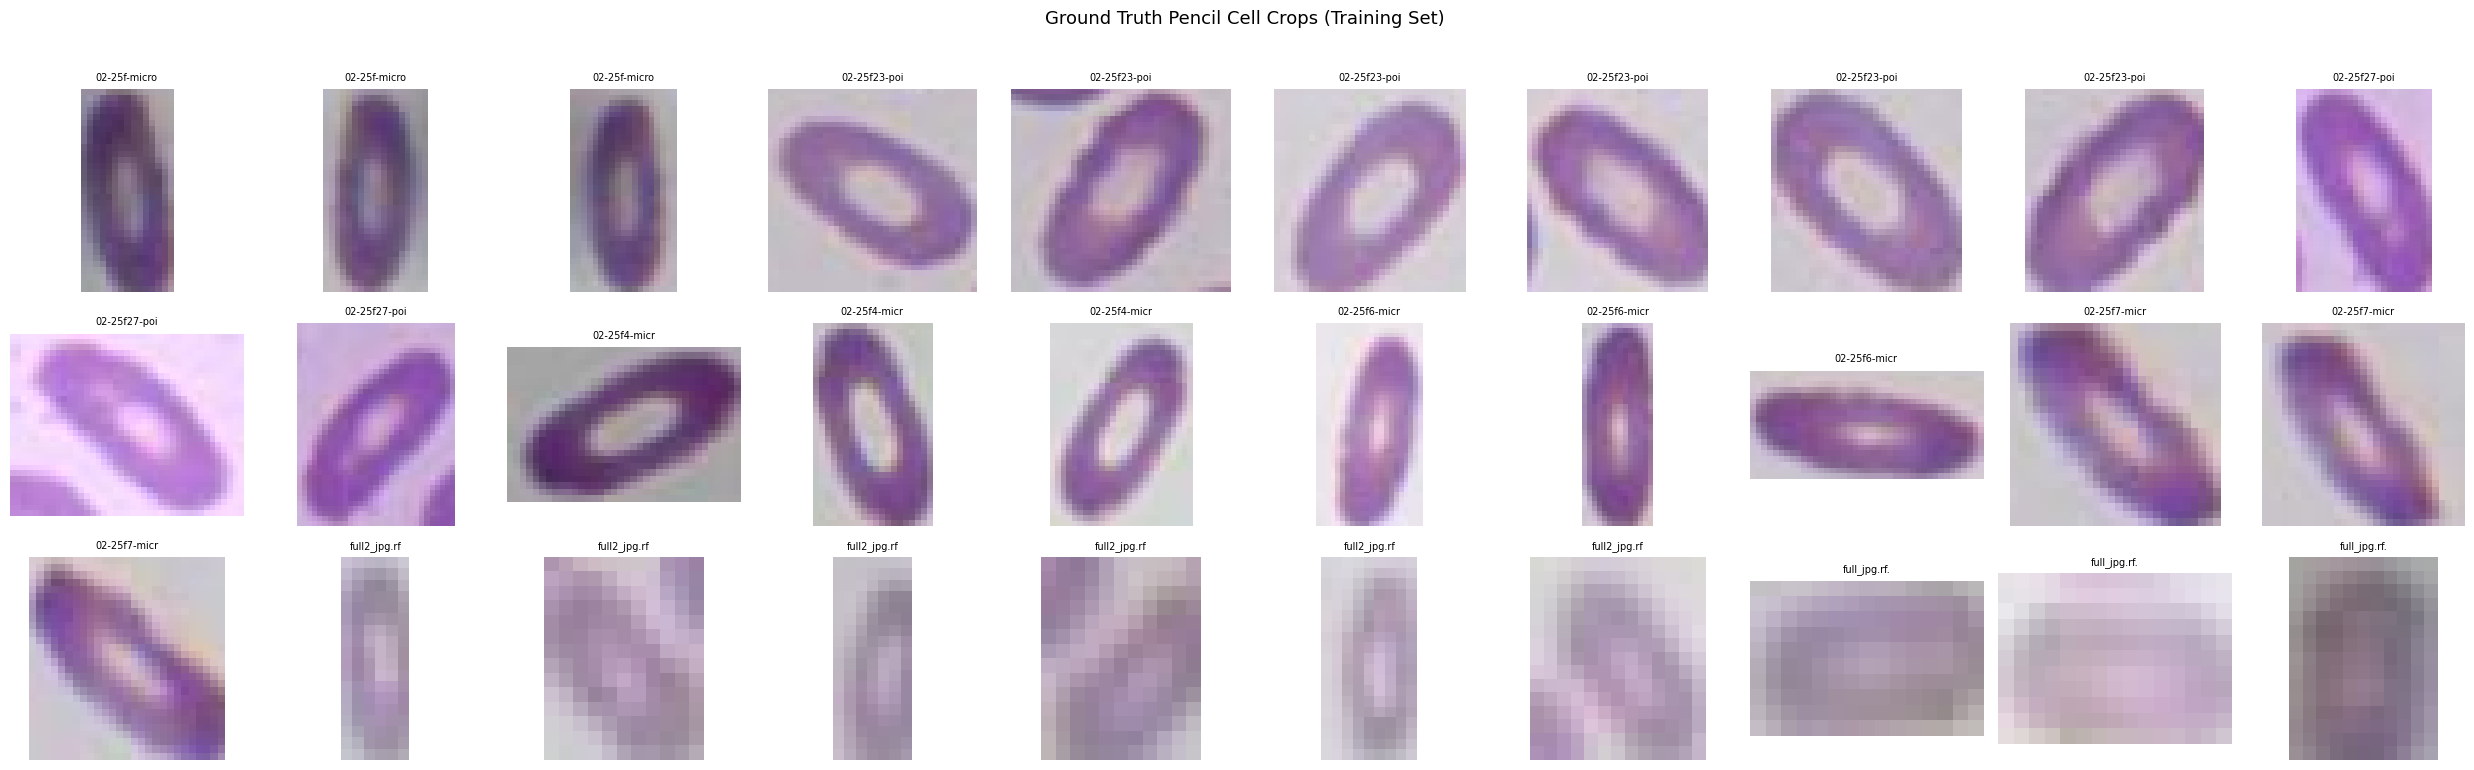


B) PER-CLASS VALIDATION METRICS
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 26.5±4.7 MB/s, size: 29.3 KB)
val: Scanning /content/drive/MyDrive/IDASrilankanDataset/valid/labels.cache... 15 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 7.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 71, len(boxes) = 83. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.6s
                   all         15         83      0.349      0.127     0.0889     0.0779
Speed: 0.8ms preprocess, 12.1ms inference, 0.0ms loss, 2.1ms postprocess per image
R

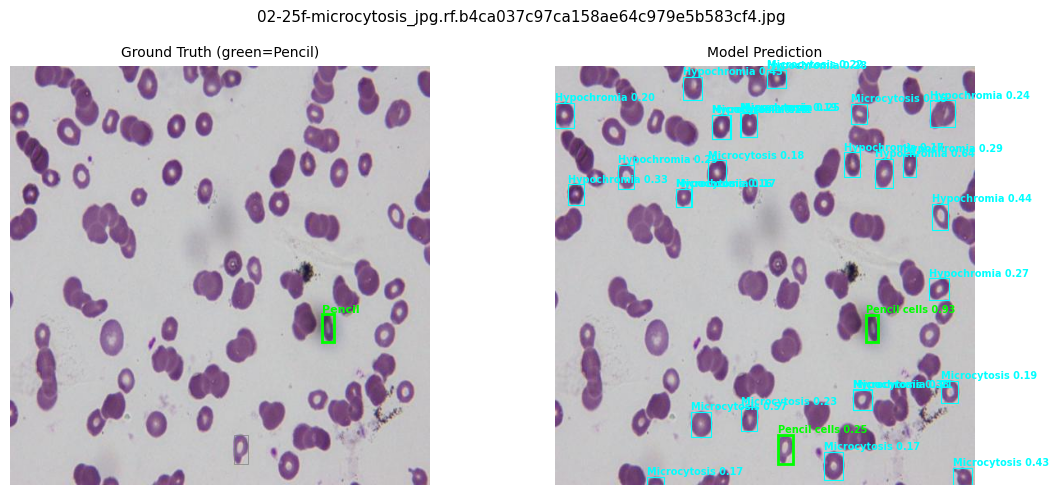

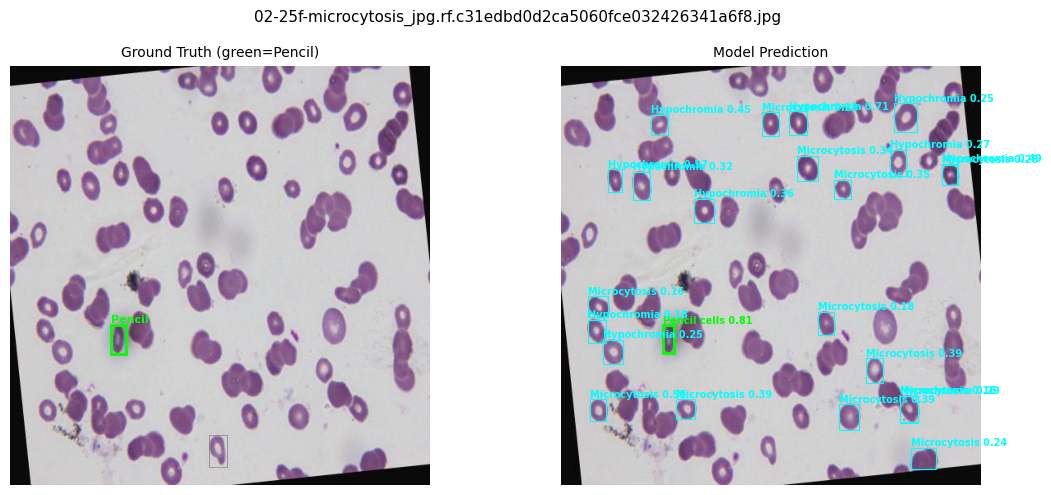

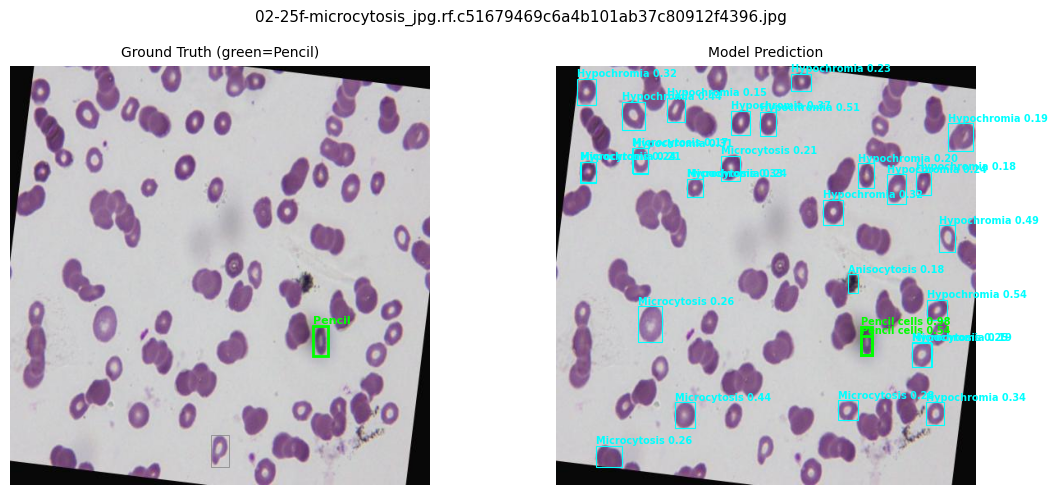

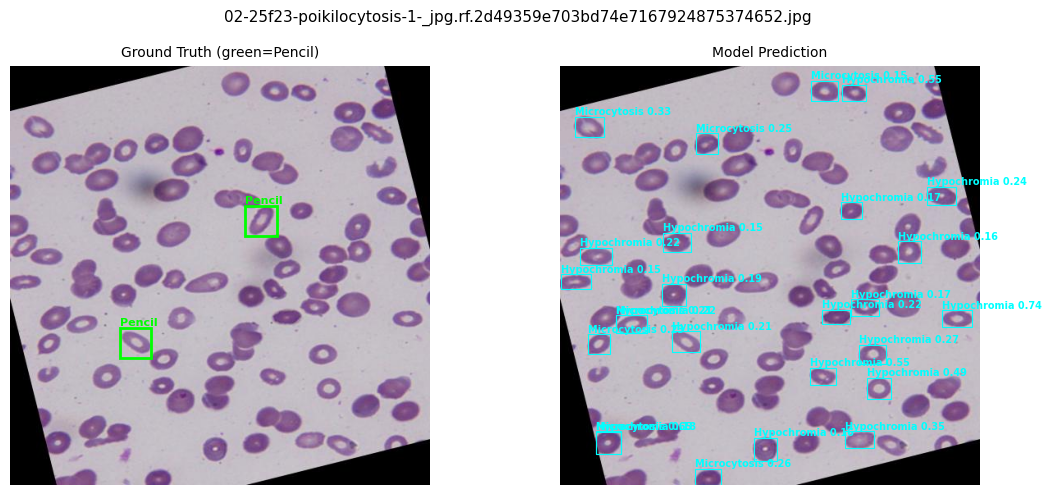

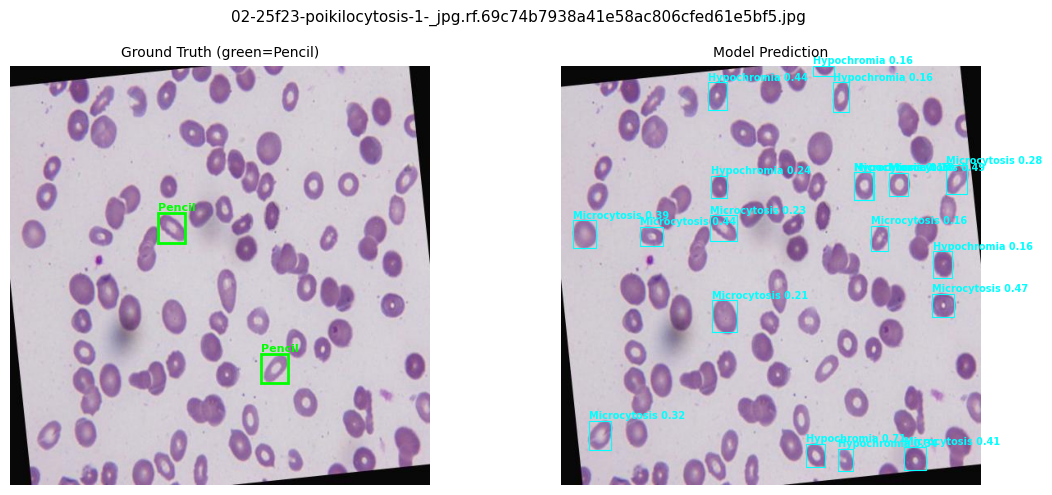

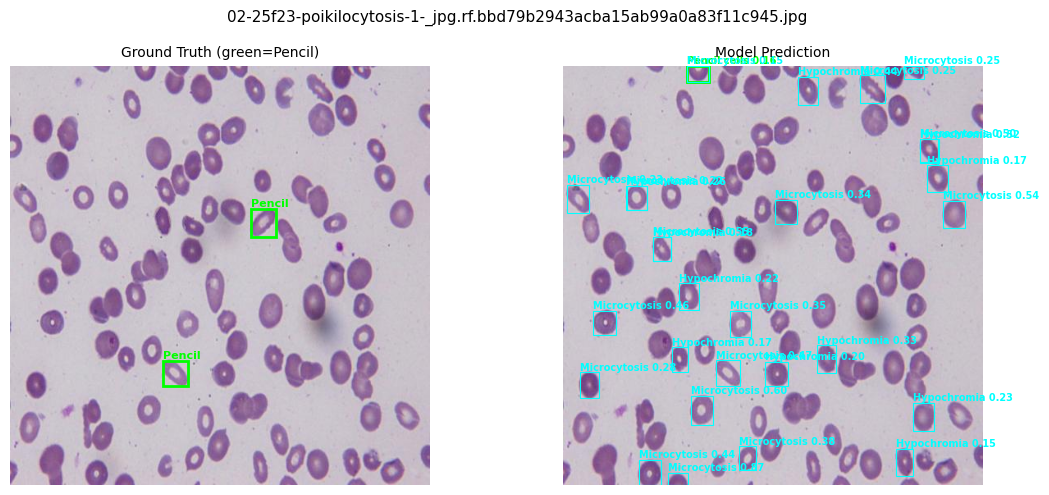

In [ ]:
# ============================================================
# 14. Analyze Pencil Cell detection — Why is it struggling?
# ============================================================
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

CLASS_NAMES = data_cfg["names"]
PENCIL_CLS = CLASS_NAMES.index("Pencil cells")

# -------------------------------------------------------
# A) Show ALL ground-truth Pencil Cell crops from training
# -------------------------------------------------------
print("=" * 60)
print("A) GROUND TRUTH — All Pencil Cell crops from training data")
print("=" * 60)
print(f"   (Class index {PENCIL_CLS} = 'Pencil cells')\n")

train_lbl_dir = os.path.join(ROOT, "train", "labels")
train_img_dir = os.path.join(ROOT, "train", "images")

pencil_crops = []
for lbl_file in sorted(glob.glob(os.path.join(train_lbl_dir, "*.txt"))):
    base = os.path.splitext(os.path.basename(lbl_file))[0]
    img_file = None
    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        p = os.path.join(train_img_dir, base + ext)
        if os.path.exists(p):
            img_file = p
            break
    if img_file is None:
        continue

    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if cls_id != PENCIL_CLS:
                continue
            if len(parts) == 5:
                img = PILImage.open(img_file)
                iw, ih = img.size
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((cx - bw / 2) * iw)
                y1 = int((cy - bh / 2) * ih)
                x2 = int((cx + bw / 2) * iw)
                y2 = int((cy + bh / 2) * ih)
                crop = img.crop((max(0, x1), max(0, y1), min(iw, x2), min(ih, y2)))
                pencil_crops.append((crop, os.path.basename(img_file)))
            elif len(parts) > 5:
                img = PILImage.open(img_file)
                iw, ih = img.size
                coords = list(map(float, parts[1:]))
                xs = [coords[i] * iw for i in range(0, len(coords), 2)]
                ys = [coords[i] * ih for i in range(1, len(coords), 2)]
                x1, y1, x2, y2 = int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))
                crop = img.crop((max(0, x1), max(0, y1), min(iw, x2), min(ih, y2)))
                pencil_crops.append((crop, os.path.basename(img_file)))

print(f"Found {len(pencil_crops)} pencil cell annotations in training set.\n")

if pencil_crops:
    cols = min(10, len(pencil_crops))
    rows = (len(pencil_crops) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.5 * rows))
    axes = np.array(axes).flatten() if len(pencil_crops) > 1 else [axes]
    for i, (crop, fname) in enumerate(pencil_crops):
        axes[i].imshow(crop)
        axes[i].set_title(fname[:12], fontsize=7)
        axes[i].axis("off")
    for i in range(len(pencil_crops), len(axes)):
        axes[i].axis("off")
    fig.suptitle("Ground Truth Pencil Cell Crops (Training Set)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# B) Per-class validation metrics
# -------------------------------------------------------
print("\n" + "=" * 60)
print("B) PER-CLASS VALIDATION METRICS")
print("=" * 60)

eval_model = YOLO(best_pt) if os.path.exists(best_pt) else model
val_results = eval_model.val(data=fixed_yaml, split="val", imgsz=IMGSZ, device=DEVICE, verbose=False)

for i, name in enumerate(CLASS_NAMES):
    p = val_results.box.class_result(i)
    print(f"  {name:20s}  P={p[0]:.3f}  R={p[1]:.3f}  mAP50={p[2]:.3f}  mAP50-95={p[3]:.3f}")

# -------------------------------------------------------
# C) Predictions vs Ground Truth on pencil cell images
# -------------------------------------------------------
print("\n" + "=" * 60)
print("C) MODEL PREDICTIONS vs GROUND TRUTH on Pencil Cell images")
print("=" * 60)

pencil_images = set()
for lbl_file in glob.glob(os.path.join(train_lbl_dir, "*.txt")):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts and int(parts[0]) == PENCIL_CLS:
                base = os.path.splitext(os.path.basename(lbl_file))[0]
                for ext in [".jpg", ".jpeg", ".png"]:
                    p = os.path.join(train_img_dir, base + ext)
                    if os.path.exists(p):
                        pencil_images.add(p)
                break

pencil_images = sorted(pencil_images)[:6]

for img_path in pencil_images:
    r = eval_model.predict(source=img_path, imgsz=IMGSZ, conf=0.15, device=DEVICE, verbose=False)[0]

    img = PILImage.open(img_path)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: ground truth
    ax1.imshow(img)
    ax1.set_title("Ground Truth (green=Pencil)", fontsize=10)
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(train_lbl_dir, base + ".txt")
    iw, ih = img.size
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if len(parts) == 5:
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * iw
                y1 = (cy - bh/2) * ih
                color = "lime" if cls_id == PENCIL_CLS else "gray"
                lw = 2 if cls_id == PENCIL_CLS else 0.5
                ax1.add_patch(patches.Rectangle((x1, y1), bw*iw, bh*ih,
                    linewidth=lw, edgecolor=color, facecolor="none"))
                if cls_id == PENCIL_CLS:
                    ax1.text(x1, y1-2, "Pencil", color="lime", fontsize=8, fontweight="bold")
            elif len(parts) > 5:
                coords = list(map(float, parts[1:]))
                xs = [coords[i]*iw for i in range(0, len(coords), 2)]
                ys = [coords[i]*ih for i in range(1, len(coords), 2)]
                bx, by = min(xs), min(ys)
                color = "lime" if cls_id == PENCIL_CLS else "gray"
                lw = 2 if cls_id == PENCIL_CLS else 0.5
                ax1.add_patch(patches.Rectangle((bx, by), max(xs)-bx, max(ys)-by,
                    linewidth=lw, edgecolor=color, facecolor="none"))
                if cls_id == PENCIL_CLS:
                    ax1.text(bx, by-2, "Pencil", color="lime", fontsize=8, fontweight="bold")
    ax1.axis("off")

    # Right: model predictions
    ax2.imshow(img)
    ax2.set_title("Model Prediction", fontsize=10)
    if r.boxes is not None and len(r.boxes) > 0:
        for b in r.boxes:
            bx1, by1, bx2, by2 = b.xyxy[0].tolist()
            cid = int(b.cls[0].item())
            conf = float(b.conf[0].item())
            name = CLASS_NAMES[cid]
            color = "lime" if cid == PENCIL_CLS else "cyan"
            lw = 2 if cid == PENCIL_CLS else 0.8
            ax2.add_patch(patches.Rectangle((bx1, by1), bx2-bx1, by2-by1,
                linewidth=lw, edgecolor=color, facecolor="none"))
            ax2.text(bx1, by1-2, f"{name} {conf:.2f}", color=color, fontsize=7, fontweight="bold")
    ax2.axis("off")

    fig.suptitle(os.path.basename(img_path), fontsize=11)
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 15. FINE-TUNE YOLOv8s — Focus on Pencil Cell Detection
# ============================================================
# Problem: Pencil cells are a minority class with near-zero
#   recall. The model is biased toward Microcytosis (82% of
#   detections). 
#
# Strategy:
#   Phase 1: Start from best.pt, freeze backbone, boost cls
#            loss weight so minority classes get more attention
#   Phase 2: Unfreeze all, lower LR, larger image size so
#            small pencil cells become more visible
#   Phase 3: Verify pencil cell detection on all pencil images
# ============================================================

import shutil
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FINETUNE_PROJECT = os.path.join(os.path.dirname(ROOT), "IDA_YOLOv8_runs")
BEST_MODEL_PATH  = "/content/drive/MyDrive/IDASrilankanDataset/yolov8s_IDA_Best_Finetuned.pt"

# Use the already-trained best.pt as starting point (not from scratch)
START_WEIGHTS = best_pt if os.path.exists(best_pt) else "yolov8s.pt"
print(f"Starting fine-tune from: {START_WEIGHTS}")

# --- Phase 1: Freeze backbone, high cls loss for minority classes ---
print("\n" + "=" * 60)
print("PHASE 1: Frozen backbone — boosted classification loss")
print("=" * 60)

model_ft = YOLO(START_WEIGHTS)

phase1_results = model_ft.train(
    data=fixed_yaml,
    epochs=60,
    imgsz=768,               # larger images to see small pencil cells
    batch=BATCH,
    device=DEVICE,
    patience=25,
    project=FINETUNE_PROJECT,
    name="yolov8s_pencil_phase1",
    exist_ok=True,
    pretrained=True,
    freeze=10,                # freeze backbone
    lr0=0.005,
    lrf=0.01,
    warmup_epochs=5,
    cos_lr=True,
    cls=1.5,                  # boost classification loss (default 0.5)
    box=7.5,                  # keep box loss default
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=20,
    translate=0.2,
    scale=0.5,
    shear=5.0,
    fliplr=0.5,
    flipud=0.2,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.15,
    plots=True,
)

phase1_dir = str(model_ft.trainer.save_dir)
phase1_best = os.path.join(phase1_dir, "weights", "best.pt")
print(f"\nPhase 1 complete. Best weights: {phase1_best}")

# --- Phase 2: Unfreeze everything, fine-tune with lower LR ---
print("\n" + "=" * 60)
print("PHASE 2: Full model fine-tuning — all layers unfrozen")
print("=" * 60)

model_ft2 = YOLO(phase1_best)

phase2_results = model_ft2.train(
    data=fixed_yaml,
    epochs=80,
    imgsz=768,
    batch=BATCH,
    device=DEVICE,
    patience=30,
    project=FINETUNE_PROJECT,
    name="yolov8s_pencil_phase2",
    exist_ok=True,
    pretrained=True,
    freeze=0,                 # all layers trainable
    lr0=0.0005,               # low LR to preserve features
    lrf=0.01,
    warmup_epochs=3,
    cos_lr=True,
    cls=1.5,
    box=7.5,
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=20,
    translate=0.2,
    scale=0.5,
    shear=5.0,
    fliplr=0.5,
    flipud=0.2,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.15,
    plots=True,
)

phase2_dir = str(model_ft2.trainer.save_dir)
phase2_best = os.path.join(phase2_dir, "weights", "best.pt")

# --- Save best model to Drive ---
shutil.copy2(phase2_best, BEST_MODEL_PATH)
print(f"\nBest fine-tuned model saved to: {BEST_MODEL_PATH}")

# --- Evaluate: Validation ---
print("\n" + "=" * 60)
print("FINE-TUNED MODEL — VALIDATION RESULTS")
print("=" * 60)

final_model = YOLO(BEST_MODEL_PATH)
val_results = final_model.val(
    data=fixed_yaml, split="val", imgsz=768, batch=BATCH, device=DEVICE
)
print(f"\n  mAP50:    {val_results.box.map50:.4f}")
print(f"  mAP50-95: {val_results.box.map:.4f}")
for i, name in enumerate(data_cfg['names']):
    p = val_results.box.class_result(i)
    print(f"  {name:20s}  P={p[0]:.3f}  R={p[1]:.3f}  mAP50={p[2]:.3f}  mAP50-95={p[3]:.3f}")

# --- Evaluate: Test ---
print("\n" + "=" * 60)
print("FINE-TUNED MODEL — TEST RESULTS")
print("=" * 60)

test_results = final_model.val(
    data=fixed_yaml, split="test", imgsz=768, batch=BATCH, device=DEVICE
)
print(f"\n  mAP50:    {test_results.box.map50:.4f}")
print(f"  mAP50-95: {test_results.box.map:.4f}")
for i, name in enumerate(data_cfg['names']):
    p = test_results.box.class_result(i)
    print(f"  {name:20s}  P={p[0]:.3f}  R={p[1]:.3f}  mAP50={p[2]:.3f}  mAP50-95={p[3]:.3f}")

# --- Phase 3: Verify pencil cell detection on ALL pencil images ---
print("\n" + "=" * 60)
print("PENCIL CELL VERIFICATION — Before vs After Fine-Tuning")
print("=" * 60)

CLASS_NAMES = data_cfg["names"]
PENCIL_CLS = CLASS_NAMES.index("Pencil cells")
train_lbl_dir = os.path.join(ROOT, "train", "labels")
train_img_dir = os.path.join(ROOT, "train", "images")

# Find all images containing pencil cell annotations
pencil_images = set()
for lbl_file in glob.glob(os.path.join(train_lbl_dir, "*.txt")):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts and int(parts[0]) == PENCIL_CLS:
                base = os.path.splitext(os.path.basename(lbl_file))[0]
                for ext in [".jpg", ".jpeg", ".png"]:
                    p = os.path.join(train_img_dir, base + ext)
                    if os.path.exists(p):
                        pencil_images.add(p)
                break
pencil_images = sorted(pencil_images)

old_model = YOLO(START_WEIGHTS)

print(f"\nFound {len(pencil_images)} images with pencil cell ground truth.\n")

for img_path in pencil_images:
    # Old model prediction
    r_old = old_model.predict(source=img_path, imgsz=768, conf=0.15, device=DEVICE, verbose=False)[0]
    # New model prediction
    r_new = final_model.predict(source=img_path, imgsz=768, conf=0.15, device=DEVICE, verbose=False)[0]

    img = PILImage.open(img_path)
    iw, ih = img.size
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # Left: Ground Truth
    ax1.imshow(img)
    ax1.set_title("Ground Truth", fontsize=10)
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(train_lbl_dir, base + ".txt")
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if len(parts) == 5:
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * iw
                y1 = (cy - bh/2) * ih
                color = "lime" if cls_id == PENCIL_CLS else "gray"
                lw = 2 if cls_id == PENCIL_CLS else 0.5
                ax1.add_patch(plt.Rectangle((x1, y1), bw*iw, bh*ih,
                    linewidth=lw, edgecolor=color, facecolor="none"))
                if cls_id == PENCIL_CLS:
                    ax1.text(x1, y1-2, "Pencil", color="lime", fontsize=8, fontweight="bold")
            elif len(parts) > 5:
                coords = list(map(float, parts[1:]))
                xs = [coords[j]*iw for j in range(0, len(coords), 2)]
                ys = [coords[j]*ih for j in range(1, len(coords), 2)]
                bx, by = min(xs), min(ys)
                color = "lime" if cls_id == PENCIL_CLS else "gray"
                lw = 2 if cls_id == PENCIL_CLS else 0.5
                ax1.add_patch(plt.Rectangle((bx, by), max(xs)-bx, max(ys)-by,
                    linewidth=lw, edgecolor=color, facecolor="none"))
                if cls_id == PENCIL_CLS:
                    ax1.text(bx, by-2, "Pencil", color="lime", fontsize=8, fontweight="bold")
    ax1.axis("off")

    # Middle: Old model
    ax2.imshow(img)
    pencil_old = 0
    if r_old.boxes is not None:
        for b in r_old.boxes:
            cid = int(b.cls[0].item())
            conf = float(b.conf[0].item())
            if cid == PENCIL_CLS:
                pencil_old += 1
            bx1, by1, bx2, by2 = b.xyxy[0].tolist()
            color = "lime" if cid == PENCIL_CLS else "cyan"
            lw = 2 if cid == PENCIL_CLS else 0.5
            ax2.add_patch(plt.Rectangle((bx1, by1), bx2-bx1, by2-by1,
                linewidth=lw, edgecolor=color, facecolor="none"))
            if cid == PENCIL_CLS:
                ax2.text(bx1, by1-2, f"Pencil {conf:.2f}", color="lime", fontsize=7, fontweight="bold")
    ax2.set_title(f"BEFORE fine-tune (Pencil: {pencil_old})", fontsize=10)
    ax2.axis("off")

    # Right: New model
    ax3.imshow(img)
    pencil_new = 0
    if r_new.boxes is not None:
        for b in r_new.boxes:
            cid = int(b.cls[0].item())
            conf = float(b.conf[0].item())
            if cid == PENCIL_CLS:
                pencil_new += 1
            bx1, by1, bx2, by2 = b.xyxy[0].tolist()
            color = "lime" if cid == PENCIL_CLS else "cyan"
            lw = 2 if cid == PENCIL_CLS else 0.5
            ax3.add_patch(plt.Rectangle((bx1, by1), bx2-bx1, by2-by1,
                linewidth=lw, edgecolor=color, facecolor="none"))
            if cid == PENCIL_CLS:
                ax3.text(bx1, by1-2, f"Pencil {conf:.2f}", color="lime", fontsize=7, fontweight="bold")
    ax3.set_title(f"AFTER fine-tune (Pencil: {pencil_new})", fontsize=10)
    ax3.axis("off")

    fig.suptitle(os.path.basename(img_path), fontsize=11)
    plt.tight_layout()
    plt.show()